# 🌍 Gamma Earth S2DR3 - Sentinel-2 Deep Resolution 3.0 (versión en español)
### Superresolución efectiva 10 bandas a 1 m de resolución espacial

---

> **Créditos y derechos de autor:**  
> Este cuaderno está basado en el módulo original **S2DR3 (Sentinel-2 Deep Resolution 3.0)** desarrollado por **Gamma.Earth**.  
> Para más información técnica, referencias o licencias comerciales, consulte:  
> 📄 [White Paper oficial](https://medium.com/@ya_71389/c71a601a2253)  
> 📩 Contacto: info@gamma.earth  
>  
> Adaptación al español realizada con fines educativos y demostrativos.

---

## 📘 Descripción

El módulo **S2DR3** permite obtener imágenes **Sentinel-2** de alta resolución (hasta **1 m/píxel**) aplicando técnicas avanzadas de **superresolución profunda (Deep Super-Resolution)** sobre las 10 bandas multiespectrales originales de 10 m y 20 m.

El resultado incluye 4 productos georreferenciados (archivos `.tif`) generados automáticamente en la carpeta `/content/output`:

| Producto | Descripción |
|-----------|--------------|
| `S2L2Ax10_T[MGRS]-[DATE]-[UID]_MS.tif` | Imagen multiespectral (10 bandas) |
| `S2L2Ax10_T[MGRS]-[DATE]-[UID]_TCI.tif` | Imagen RGB color verdadero |
| `S2L2Ax10_T[MGRS]-[DATE]-[UID]_NDVI.tif` | Imagen NDVI (color falso) |
| `S2L2Ax10_T[MGRS]-[DATE]-[UID]_IRP.tif` | Imagen infrarroja (color falso) |

**Orden de bandas:**  
`B02, B03, B04, B05, B06, B07, B08, B8A, B11, B12`

---

## ⚙️ Instrucciones de uso (un clic)

1. Abrir este notebook en **Google Colab**  
2. En el menú superior, ir a: `Entorno de ejecución` → `Cambiar tipo de entorno de ejecución` → seleccionar **GPU T4**  
3. Ejecutar todas las celdas (`Ctrl+F9` o “Ejecutar todo”)  


In [ ]:
# =============================================================
# 🛰️ INSTALACIÓN LIBRERÍAS Y COMPLEMENTOS
# =============================================================

# 1) Instalar s2dr3
!pip -q install https://github.com/ccalvocm/S2DR3/raw/refs/heads/main/model/s2dr3-20260827.1-cp313-cp313-linux_x86_64.whl

# 2) Instalar numpy y scipy PRIMERO, por separado
# !pip install -q --force-reinstall --no-deps numpy==1.26.4 scipy==1.13.0
!pip install -q --force-reinstall --no-deps numpy scipy


# 3) Asegurarnos de tener Cython para compilar si hace falta
!pip install -q cython

# 4) Instalar scikit-image SIN build isolation, para que use el numpy 1.26.4 ya instalado
# !pip install -q --force-reinstall --no-deps --no-cache-dir --no-build-isolation scikit-image==0.22.0
!pip install -q --force-reinstall --no-deps --no-cache-dir --no-build-isolation scikit-image


# 3) Reiniciar el kernel UNA sola vez
import IPython
IPython.Application.instance().kernel.do_shutdown(True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 226.1 MB/s eta 0:00:00


{'status': 'ok', 'restart': True}

In [ ]:
# =============================================================
# 🛰️ PROCESAMIENTO
# =============================================================

import s2dr3.inferutils

# =============================================================
# 🌎 Parámetros de entrada
# =============================================================

# Coordenadas del punto central (longitud, latitud)
# ⚠️ IMPORTANTE: el formato es (X, Y)

lonlat = (-70.616097,-33.4386186)  # Ejemplo: CIREN
# lonlat = (-79.203, -4.008)

# Fecha objetivo (AAAA-MM-DD)
# El modelo descargará la escena Sentinel-2 más cercana a esta fecha
# Nota: pueden existir nubes, se recomienda verificar en:
# https://browser.dataspace.copernicus.eu

# date = '2022-06-20'
date = '2026-08-23'

# =============================================================
# 🚀 Ejecución del modelo
# =============================================================

# Genera los productos en alta resolución (1 m/píxel)
# Los resultados se guardarán en /content/output
s2dr3.inferutils.test(lonlat, date)

Fetching data for T19HCD-1cf2ceef1-20260820 
ERROR: Sentinel-2 download failed.


FileNotFoundError: [Errno 2] No such file or directory: '/tmp/.__373dd582/b10m10.tif'

In [ ]:
# =============================================================
# S2DR3 — FIX S3 ACCESS
# =============================================================

import os
import boto3
from botocore import UNSIGNED
from botocore.config import Config

# Force anonymous/public S3 access
os.environ.pop("AWS_ACCESS_KEY_ID", None)
os.environ.pop("AWS_SECRET_ACCESS_KEY", None)
os.environ["AWS_DEFAULT_REGION"] = "us-east-1"

# boto3 anonymous client
s3_public = boto3.client(
    "s3",
    region_name="us-east-1",
    config=Config(signature_version=UNSIGNED)
)

print("Anonymous S3 client initialized.")

Anonymous S3 client initialized.


In [ ]:
# =============================================================
# Configure GDAL for unsigned S3
# =============================================================

from osgeo import gdal

gdal.SetConfigOption("AWS_NO_SIGN_REQUEST", "YES")
gdal.SetConfigOption("AWS_REGION", "us-east-1")

print("GDAL AWS_NO_SIGN_REQUEST =",
      gdal.GetConfigOption("AWS_NO_SIGN_REQUEST"))

GDAL AWS_NO_SIGN_REQUEST = YES


In [ ]:
# ============================================================
# S2DR3 FIX — download Sentinel-2 COGs directly with GDAL
# ============================================================

import os
import glob
import shutil
from osgeo import gdal

# Public S3
gdal.SetConfigOption("AWS_NO_SIGN_REQUEST", "YES")
gdal.SetConfigOption("AWS_REGION", "us-east-1")

# Your requested location/date
lon, lat = -70.616097, -33.4386186
date = "2026-08-23"

# ------------------------------------------------------------
# 1. Ask S2DR3's own API for the best Sentinel-2 scene
# ------------------------------------------------------------

import requests

url = "https://us-central1-s2dr202502.cloudfunctions.net/getS2BestDate"

params = {
    "lon": lon,
    "lat": lat,
    "date": date
}

r = requests.get(url, params=params, timeout=60)

print("API:", r.status_code)

if r.status_code != 200:
    raise RuntimeError(r.text)

info = r.json()

print("Scene:", info.get("id"))
print("S3 path:", info.get("s3path"))

# ------------------------------------------------------------
# 2. Locate the scene in the public Sentinel COG bucket
# ------------------------------------------------------------

s3path = info["s3path"]

base = "/vsis3/sentinel-cogs/" + s3path

print("\nChecking:")
print(base)

contents = gdal.ReadDir(base)

if not contents:
    raise RuntimeError("Scene exists in API but GDAL cannot list its S3 directory.")

print("\nFiles found:")
for x in contents:
    print(" ", x)

# ------------------------------------------------------------
# 3. Find the 10-m bands
# ------------------------------------------------------------

bands = {}

for x in contents:
    name = x.lower()

    if "b02" in name:
        bands["B02"] = x
    elif "b03" in name:
        bands["B03"] = x
    elif "b04" in name:
        bands["B04"] = x
    elif "b08" in name:
        bands["B08"] = x

print("\n10-m bands:")
for k, v in bands.items():
    print(k, "=>", v)

if len(bands) != 4:
    raise RuntimeError(
        f"Could not find all four 10-m bands. Found: {bands}"
    )

# ------------------------------------------------------------
# 4. Build VRT and convert to the format S2DR3 expects
# ------------------------------------------------------------

tmp = "/tmp/s2dr3_direct"
os.makedirs(tmp, exist_ok=True)

vrt = os.path.join(tmp, "b10m10.vrt")
out = os.path.join(tmp, "b10m10.tif")

sources = [
    base + "/" + bands["B02"],
    base + "/" + bands["B03"],
    base + "/" + bands["B04"],
    base + "/" + bands["B08"],
]

print("\nBuilding VRT...")

gdal.BuildVRT(
    vrt,
    sources,
    separate=True
)

print("Creating:", out)

gdal.Translate(
    out,
    vrt,
    format="GTiff",
    creationOptions=[
        "TILED=YES",
        "COMPRESS=LZW"
    ]
)

print("\nCreated:")
print(out)

ds = gdal.Open(out)

if ds is None:
    raise RuntimeError("Could not open generated b10m10.tif")

print(
    "Size:",
    ds.RasterXSize,
    "x",
    ds.RasterYSize,
    "bands:",
    ds.RasterCount
)

ds = None

# ------------------------------------------------------------
# 5. Copy it into the exact S2DR3 temporary directory
# ------------------------------------------------------------

# Find the directory generated by the failed S2DR3 run
dirs = sorted(
    glob.glob("/tmp/.__*"),
    key=os.path.getmtime,
    reverse=True
)

if not dirs:
    raise RuntimeError("No S2DR3 temporary directory found.")

target_dir = dirs[0]

target = os.path.join(target_dir, "b10m10.tif")

shutil.copy2(out, target)

print("\nS2DR3 temporary directory:")
print(target_dir)

print("\nCopied:")
print(target)

print("\nDONE.")

API: 200
Scene: S2B_37MCV_20250201_0_L2A
S3 path: sentinel-s2-l2a-cogs/37/M/CV/2025/2/S2B_37MCV_20250201_0_L2A

Checking:
/vsis3/sentinel-cogs/sentinel-s2-l2a-cogs/37/M/CV/2025/2/S2B_37MCV_20250201_0_L2A

Files found:
  AOT.tif
  B01.tif
  B02.tif
  B03.tif
  B04.tif
  B05.tif
  B06.tif
  B07.tif
  B08.tif
  B09.tif
  B11.tif
  B12.tif
  B8A.tif
  L2A_PVI.tif
  S2B_37MCV_20250201_0_L2A.json
  SCL.tif
  TCI.tif
  WVP.tif
  granule_metadata.xml
  preview.jpg
  tileinfo_metadata.json

10-m bands:
B02 => B02.tif
B03 => B03.tif
B04 => B04.tif
B08 => B08.tif

Building VRT...


/usr/local/lib/python3.12/dist-packages/osgeo/gdal.py:312: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


Creating: /tmp/s2dr3_direct/b10m10.tif

Created:
/tmp/s2dr3_direct/b10m10.tif
Size: 10980 x 10980 bands: 4

S2DR3 temporary directory:
/tmp/.__373dd582

Copied:
/tmp/.__373dd582/b10m10.tif

DONE.


Fetching data for T19HCD-1cf2ceef1-20260820 .......... done. 
Processing S2L2A_T19HCD-1cf2ceef1-20260820_MS . done 
Postprocessing S2L2A_T19HCD-1cf2ceef1-20260820_MS ... failed  failed  failed  failed  failed  failed  done

Find results at the following path: /content/output
Click the link below for preview:

https://gamayos.github.io/gamma-earth-api/s2dr3-demo-20250305.html?ds=CL-T19HCD-1cf2ceef1-20260820#15/-33.4386/-70.6161



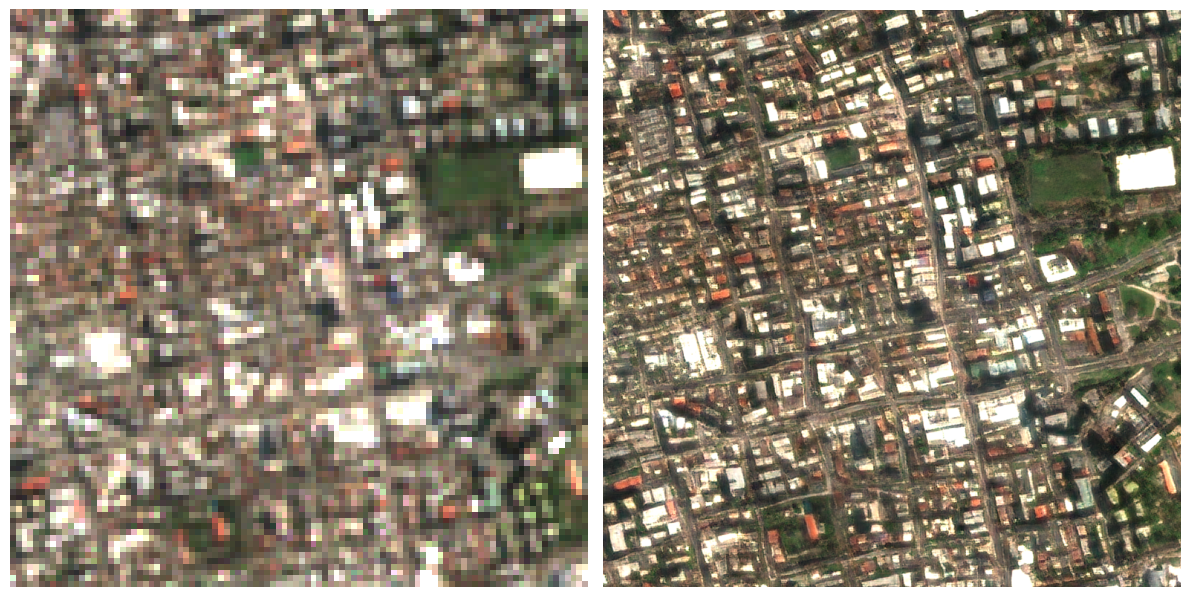

In [ ]:
import s2dr3.inferutils

s2dr3.inferutils.test(
    (-70.616097, -33.4386186),
    "2026-08-23"
)

Licencia
Copyright (c) Gamma Earth Sarl

El software se proporciona para pruebas, evaluación de rendimiento y validación. Todos los derechos reservados por el titular de los derechos de autor. Para ampliar su funcionalidad y uso comercial, contacte con info@gamma.earth.

Para publicaciones académicas relacionadas con S2DR3, utilice la siguiente referencia:

Yosef Akhtman, S2DR3: Superresolución efectiva de imagen única de 10 bandas y 10x para Sentinel-2. Medium: https://medium.com/@ya_71389/c71a601a2253